# 🌾 BÁO CÁO ĐỐI SOÁT & ĐÁNH GIÁ TOÀN DIỆN CÁC MÔ HÌNH PHÂN ĐOẠN HẠT LÚA
## (Comprehensive Benchmark: YOLOv8, YOLOv10, YOLOv12, YOLOv26 & MobileSAM)

> **💡 Hướng dẫn nhanh khi chạy trên Google Colab:**
> - Khi chạy **Cell 1**, Colab sẽ hiển thị yêu cầu: chọn **"Kết nối với Google Drive" (Connect to Google Drive)**.
> - Notebook tự động dò tìm thư mục dự án và cài đặt thư viện cần thiết.
>
> **📌 Lưu ý quan trọng về các nhóm mô hình:**
> - **Nhóm Phân đoạn Mặt nạ (Instance Segmentation)**: Bao gồm `yolov8n`, `yolov8s`, `yolov8m`, `yolov12_mobileSam`, và `yolov26`. Các mô hình này có nhánh xuất mặt nạ (Mask Head) nên tham gia đầy đủ Bảng 2 (Box) và Bảng 3 (Mask).
> - **Nhóm Nhận diện Hộp (Object Detection)**: Bao gồm `yolov10n` và `yolov10s`. Kiến trúc YOLOv10 nguyên bản được thiết kế chuyên biệt cho phát hiện vật thể (Detection), **không có nhánh Mask**, do đó được đánh giá trong Bảng 2 (Bounding Box) và không tham gia Bảng 3 (Mask Segmentation).

---
### 📌 Danh sách 7 mô hình được đánh giá:
1. **YOLOv8n-seg** (Nano Segmentation)
2. **YOLOv8s-seg** (Small Segmentation)
3. **YOLOv8m-seg** (Medium Segmentation)
4. **YOLOv10n** (Nano Detection - Hộp giới hạn)
5. **YOLOv10s** (Small Detection - Hộp giới hạn)
6. **YOLOv12s-seg + MobileSAM** (Cấu hình lai phân đoạn)
7. **YOLOv26m-seg** (Mô hình phân đoạn SOTA chính xác cao nhất)
---


In [49]:
# ==============================================================================
# 1. THIẾT LẬP MÔI TRƯỜNG & TỰ ĐỘNG KẾT NỐI GOOGLE DRIVE (CHO CẢ LOCAL & COLAB)
# ==============================================================================
import os
import sys
import warnings
from pathlib import Path

# --- 1.1 Tự động phát hiện Google Colab và Mount Google Drive ---
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
if IN_COLAB:
    print("🚀 Phát hiện môi trường Google Colab. Đang kết nối Google Drive...")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print(f"⚠️ Lưu ý khi mount Google Drive: {e}")

    # Cài đặt thư viện bổ trợ nếu môi trường Colab chưa có
    import subprocess
    try:
        import openpyxl, yaml, seaborn
    except ImportError:
        print("📦 Đang cài đặt các thư viện cần thiết (seaborn, openpyxl, pyyaml)...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn", "openpyxl", "pyyaml"])

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị Matplotlib & Seaborn
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 150

# --- 1.2 Tự động xác định đường dẫn BASE_DIR (Linh hoạt Local & Google Colab) ---
override = os.environ.get("RICAI_PROJECT_ROOT")
candidates = [Path(override)] if override else [
    Path.cwd(),
    *Path.cwd().parents,
    Path("/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"),
]

# Hỗ trợ trường hợp Google Drive Shortcut ID (.shortcut-targets-by-id)
shortcut_root = Path("/content/drive/.shortcut-targets-by-id")
if not override and shortcut_root.exists():
    candidates.extend(sorted(shortcut_root.glob("*/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES")))

BASE_DIR = None

# Trường hợp 1: Notebook đang mở trực tiếp tại thư mục RESULTS/Segmentation Model Results
if (Path.cwd() / "yolov8n").is_dir() and (Path.cwd() / "yolov8s").is_dir():
    BASE_DIR = Path.cwd()
else:
    # Trường hợp 2: Quét qua các candidates tìm thư mục chứa 6 model
    for candidate in candidates:
        target = candidate / "RESULTS" / "Segmentation Model Results" if (candidate / "RESULTS").is_dir() else candidate
        if (target / "yolov8n").is_dir() and (target / "yolov8s").is_dir():
            BASE_DIR = target
            break

# Trường hợp 3: Quét sâu trong /content/drive nếu người dùng đặt tên thư mục khác
if BASE_DIR is None and Path("/content/drive").exists():
    for p in Path("/content/drive").glob("**/Segmentation Model Results"):
        if (p / "yolov8n").is_dir() and (p / "yolov8s").is_dir():
            BASE_DIR = p
            break

if BASE_DIR is None:
    raise FileNotFoundError(
        "❌ Không tìm thấy thư mục 'Segmentation Model Results'!\n"
        "👉 HƯỚNG DẪN XỬ LÝ TRÊN COLAB:\n"
        "1. Hãy chắc chắn bạn đã nhấn 'Connect to Google Drive' khi Colab hỏi quyền truy cập.\n"
        "2. Nếu thư mục được người khác chia sẻ: Vào Google Drive > 'Được chia sẻ với tôi' > "
        "Chuột phải vào thư mục MAIN_SOURCES > Chọn 'Thêm lối tắt vào Drive' (Add shortcut) > Lưu vào 'MyDrive'.\n"
        "3. Hoặc gán đường dẫn thủ công: BASE_DIR = Path('/content/drive/MyDrive/.../Segmentation Model Results')"
    )

CHARTS_DIR = BASE_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Môi trường thực thi: {'Google Colab' if IN_COLAB else 'Local Máy tính'}")
print(f"📂 Thư mục làm việc (BASE_DIR): {BASE_DIR}")
print(f"📊 Thư mục lưu biểu đồ (CHARTS_DIR): {CHARTS_DIR}")

# Kiểm tra các thư mục model đã sẵn sàng
expected_models = ["yolov8n", "yolov8s", "yolov8m", "yolov10n", "yolov10s", "yolov12_mobileSam"]
found_models = [m for m in expected_models if (BASE_DIR / m).is_dir()]
print(f"🎯 Đã phát hiện {len(found_models)}/{len(expected_models)} thư mục mô hình: {found_models}")

# --- 1.3 Cấu hình bảng số liệu chuẩn tương phản cao (Nền sáng - Chữ tối #111111) ---
from matplotlib.colors import LinearSegmentedColormap

CMAP_BLUE = LinearSegmentedColormap.from_list("soft_blue", ["#ffffff", "#bfdbfe"])
CMAP_GREEN = LinearSegmentedColormap.from_list("soft_green", ["#ffffff", "#bbf7d0"])
CMAP_ORANGE = LinearSegmentedColormap.from_list("soft_orange", ["#ffffff", "#fed7aa"])

def format_academic_table(styler, caption=""):
    return styler.set_caption(caption).set_table_styles([
        {"selector": "table", "props": [
            ("background-color", "#ffffff !important"),
            ("color", "#111111 !important"),
            ("border-collapse", "collapse"),
            ("font-family", "Arial, Helvetica, sans-serif"),
            ("font-size", "13px"),
            ("margin", "12px 0"),
            ("box-shadow", "0 1px 4px rgba(0,0,0,0.08)")
        ]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-size", "14px"),
            ("font-weight", "bold"),
            ("color", "#111111 !important"),
            ("padding", "8px 0"),
            ("text-align", "left")
        ]},
        {"selector": "th", "props": [
            ("background-color", "#e9ecef !important"),
            ("color", "#111111 !important"),
            ("font-weight", "bold"),
            ("border", "1px solid #ced4da"),
            ("padding", "8px 12px"),
            ("text-align", "center"),
            ("white-space", "nowrap")
        ]},
        {"selector": "td", "props": [
            ("background-color", "#ffffff"),
            ("color", "#111111 !important"),
            ("border", "1px solid #dee2e6"),
            ("padding", "8px 12px"),
            ("text-align", "center")
        ]},
        {"selector": "tr:hover td", "props": [
            ("opacity", "0.95")
        ]}
    ]).set_properties(**{"color": "#111111 !important"})


🚀 Phát hiện môi trường Google Colab. Đang kết nối Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Môi trường thực thi: Google Colab
📂 Thư mục làm việc (BASE_DIR): /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results
📊 Thư mục lưu biểu đồ (CHARTS_DIR): /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/charts
🎯 Đã phát hiện 6/6 thư mục mô hình: ['yolov8n', 'yolov8s', 'yolov8m', 'yolov10n', 'yolov10s', 'yolov12_mobileSam']


In [50]:
# ==============================================================================
# 2. THU THẬP & TRÍCH XUẤT DỮ LIỆU ĐỊNH LƯỢNG TỪ CÁC THƯ MỤC MODEL
# ==============================================================================

# Tự động phát hiện toàn bộ các thư mục mô hình có chứa results.csv
priority_order = ["yolov8n", "yolov8s", "yolov8m", "yolov10n", "yolov10s", "yolov12_mobileSam", "yolov26"]
available_folders = [f.name for f in BASE_DIR.iterdir() if f.is_dir() and (f / "results.csv").exists()]
model_folders = [m for m in priority_order if m in available_folders] + [m for m in available_folders if m not in priority_order]

data_records = []
all_results_dfs = {}

for name in model_folders:
    folder = BASE_DIR / name
    res_csv = folder / "results.csv"
    if not res_csv.exists():
        continue

    df_res = pd.read_csv(res_csv)
    df_res.columns = [c.strip() for c in df_res.columns]
    all_results_dfs[name] = df_res

    args_yaml = folder / "args.yaml"
    cfg = {}
    if args_yaml.exists():
        with open(args_yaml, 'r', encoding='utf-8') as f:
            cfg = yaml.safe_load(f)

    best_pt = folder / "weights" / "best.pt"
    size_mb = round(best_pt.stat().st_size / (1024 * 1024), 2) if best_pt.exists() else np.nan

    is_seg = "metrics/mAP50(M)" in df_res.columns
    task = "Instance Segmentation" if is_seg else "Object Detection"

    total_time_sec = float(df_res["time"].iloc[-1]) if "time" in df_res.columns else np.nan
    total_time_hr = round(total_time_sec / 3600, 2) if pd.notna(total_time_sec) else np.nan

    best_box_idx = df_res["metrics/mAP50-95(B)"].idxmax()
    b_epoch = int(df_res.loc[best_box_idx, "epoch"])
    b_p = float(df_res.loc[best_box_idx, "metrics/precision(B)"])
    b_r = float(df_res.loc[best_box_idx, "metrics/recall(B)"])
    b_map50 = float(df_res.loc[best_box_idx, "metrics/mAP50(B)"])
    b_map50_95 = float(df_res.loc[best_box_idx, "metrics/mAP50-95(B)"])
    b_f1 = (2 * b_p * b_r / (b_p + b_r)) if (b_p + b_r) > 0 else 0.0

    if is_seg:
        best_mask_idx = df_res["metrics/mAP50-95(M)"].idxmax()
        m_epoch = int(df_res.loc[best_mask_idx, "epoch"])
        m_p = float(df_res.loc[best_mask_idx, "metrics/precision(M)"])
        m_r = float(df_res.loc[best_mask_idx, "metrics/recall(M)"])
        m_map50 = float(df_res.loc[best_mask_idx, "metrics/mAP50(M)"])
        m_map50_95 = float(df_res.loc[best_mask_idx, "metrics/mAP50-95(M)"])
        m_f1 = (2 * m_p * m_r / (m_p + m_r)) if (m_p + m_r) > 0 else 0.0
    else:
        m_epoch, m_p, m_r, m_map50, m_map50_95, m_f1 = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    last_row = df_res.iloc[-1]

    data_records.append({
        "Model": name,
        "Task": task,
        "Weight Size (MB)": size_mb,
        "Total Time (h)": total_time_hr,
        "Total Time (s)": total_time_sec,
        "Epochs": len(df_res),
        "Batch Size": cfg.get("batch", 8),
        "Image Size": cfg.get("imgsz", 640),
        "Optimizer": cfg.get("optimizer", "SGD"),
        "LR_Initial": cfg.get("lr0", 0.01),
        # Best Box
        "Best Box Epoch": b_epoch,
        "Box Precision": round(b_p, 4),
        "Box Recall": round(b_r, 4),
        "Box F1": round(b_f1, 4),
        "Box mAP50": round(b_map50, 4),
        "Box mAP50-95": round(b_map50_95, 4),
        # Best Mask
        "Best Mask Epoch": m_epoch,
        "Mask Precision": round(m_p, 4) if pd.notna(m_p) else np.nan,
        "Mask Recall": round(m_r, 4) if pd.notna(m_r) else np.nan,
        "Mask F1": round(m_f1, 4) if pd.notna(m_f1) else np.nan,
        "Mask mAP50": round(m_map50, 4) if pd.notna(m_map50) else np.nan,
        "Mask mAP50-95": round(m_map50_95, 4) if pd.notna(m_map50_95) else np.nan,
        # Epoch 100 Box
        "Final Box mAP50": round(float(last_row["metrics/mAP50(B)"]), 4),
        "Final Box mAP50-95": round(float(last_row["metrics/mAP50-95(B)"]), 4),
        # Epoch 100 Mask
        "Final Mask mAP50": round(float(last_row["metrics/mAP50(M)"]), 4) if is_seg else np.nan,
        "Final Mask mAP50-95": round(float(last_row["metrics/mAP50-95(M)"]), 4) if is_seg else np.nan,
    })

df_summary = pd.DataFrame(data_records)
print(f"✅ Đã nạp thành công dữ liệu của {len(df_summary)} mô hình: {list(df_summary['Model'])}")


✅ Đã nạp thành công dữ liệu của 7 mô hình: ['yolov8n', 'yolov8s', 'yolov8m', 'yolov10n', 'yolov10s', 'yolov12_mobileSam', 'yolov26']


---
### 📋 BẢNG 1: TỔNG QUAN KIẾN TRÚC & THÔNG SỐ HUẤN LUYỆN
Bảng này mô tả các đặc tính cấu hình phần cứng/phần mềm, dung lượng mô hình và thời gian huấn luyện 100 epochs.


In [51]:
# Bảng 1: Cấu hình kiến trúc & thời gian huấn luyện
t1_cols = [
    "Model", "Task", "Weight Size (MB)", "Epochs", "Batch Size",
    "Image Size", "Optimizer", "Total Time (h)", "Total Time (s)"
]
df_table1 = df_summary[t1_cols].copy()
df_table1["Thời gian / Epoch (s)"] = (df_table1["Total Time (s)"] / df_table1["Epochs"]).round(2)
df_table1 = df_table1.drop(columns=["Total Time (s)"])

# Hiển thị bảng định dạng tương phản cao (Nền sáng - Chữ tối #111111)
s1 = df_table1.style.format({"Weight Size (MB)": "{:.2f}", "Total Time (h)": "{:.2f}", "Thời gian / Epoch (s)": "{:.2f}"})\
    .background_gradient(subset=["Weight Size (MB)"], cmap=CMAP_BLUE)\
    .background_gradient(subset=["Total Time (h)"], cmap=CMAP_ORANGE)
format_academic_table(s1, "<b>Bảng 1: Tổng quan Kiến trúc và Tham số Huấn luyện</b>")


,Model,Task,Weight Size (MB),Epochs,Batch Size,Image Size,Optimizer,Total Time (h),Thời gian / Epoch (s)
0,yolov8n,Instance Segmentation,6.48,100,8,640,SGD,1.84,66.38
1,yolov8s,Instance Segmentation,22.76,100,8,640,SGD,1.89,68.04
2,yolov8m,Instance Segmentation,52.30,100,8,640,SGD,2.90,104.51
3,yolov10n,Object Detection,5.49,100,8,640,SGD,1.80,64.80
4,yolov10s,Object Detection,15.77,100,8,640,SGD,1.77,63.80
5,yolov12_mobileSam,Instance Segmentation,19.34,100,8,640,SGD,2.49,89.72
6,yolov26,Instance Segmentation,51.98,100,8,640,SGD,4.19,150.97


---
### 📦 BẢNG 2: SO SÁNH CHỈ SỐ BOUNDING BOX (HỘP GIỚI HẠN)
Chỉ số hộp giới hạn đánh giá khả năng định vị chính xác vị trí của từng hạt lúa trên ảnh bề mặt.
- **Precision (Độ chính xác)**: Tỷ lệ hạt dự đoán đúng trên tổng số hạt mô hình tìm ra.
- **Recall (Độ nhạy)**: Tỷ lệ hạt tìm được trên tổng số hạt thực tế có trong ảnh.
- **F1-Score**: Trung bình điều hòa giữa Precision và Recall.
- **mAP@50**: Độ chính xác trung bình tại ngưỡng IoU = 0.50.
- **mAP@50-95**: Độ chính xác trung bình tích lũy từ IoU = 0.50 đến 0.95 (thước đo chuẩn COCO khắt khe nhất).


In [52]:
# Bảng 2: Chỉ số Bounding Box
t2_cols = [
    "Model", "Best Box Epoch", "Box Precision", "Box Recall",
    "Box F1", "Box mAP50", "Box mAP50-95", "Final Box mAP50-95"
]
df_table2 = df_summary[t2_cols].copy()
df_table2["Δ mAP (Best - Final)"] = (df_table2["Box mAP50-95"] - df_table2["Final Box mAP50-95"]).round(4)

s2 = df_table2.style.format({
    "Box Precision": "{:.4f}", "Box Recall": "{:.4f}", "Box F1": "{:.4f}",
    "Box mAP50": "{:.4f}", "Box mAP50-95": "{:.4f}", "Final Box mAP50-95": "{:.4f}",
    "Δ mAP (Best - Final)": "{:+.4f}"
})\
.highlight_max(subset=["Box F1", "Box mAP50", "Box mAP50-95"], props="background-color: #d1e7dd !important; color: #0f5132 !important; font-weight: bold;")\
.highlight_min(subset=["Box mAP50-95"], props="background-color: #f8d7da !important; color: #842029 !important; font-weight: bold;")
format_academic_table(s2, "<b>Bảng 2: Hiệu năng Bounding Box (Phát hiện Vị trí Hạt Lúa)</b>")


,Model,Best Box Epoch,Box Precision,Box Recall,Box F1,Box mAP50,Box mAP50-95,Final Box mAP50-95,Δ mAP (Best - Final)
0,yolov8n,90,0.9617,0.9494,0.9555,0.9698,0.8993,0.8936,+0.0057
1,yolov8s,74,0.9672,0.9458,0.9564,0.9705,0.9041,0.8839,+0.0202
2,yolov8m,92,0.9583,0.9530,0.9556,0.9756,0.9150,0.9147,+0.0003
3,yolov10n,71,0.9633,0.9357,0.9493,0.9618,0.8902,0.8817,+0.0085
4,yolov10s,89,0.9614,0.9531,0.9572,0.9744,0.9118,0.9097,+0.0021
5,yolov12_mobileSam,96,0.9553,0.9533,0.9543,0.9704,0.9002,0.8959,+0.0043
6,yolov26,96,0.9123,0.9220,0.9171,0.9571,0.9195,0.9185,+0.0010


---
### 🎭 BẢNG 3: SO SÁNH CHỈ SỐ PHÂN ĐOẠN MẶT NẠ (MASK SEGMENTATION)
Chỉ số Mask Segmentation là tiêu chí cốt lõi nhất của bài toán bóc tách hạt lúa 3D:
- Chỉ áp dụng cho các mô hình có nhánh phân đoạn: `yolov8n`, `yolov8s`, `yolov8m`, `yolov12_mobileSam`.
- Đo lường độ khớp chính xác từng pixel biên dạng hạt để tính toán chiều dài, chiều rộng và thể tích ellipsoid.


In [53]:
# Bảng 3: Chỉ số Mask Segmentation
t3_cols = [
    "Model", "Best Mask Epoch", "Mask Precision", "Mask Recall",
    "Mask F1", "Mask mAP50", "Mask mAP50-95", "Final Mask mAP50-95"
]
df_table3 = df_summary[df_summary["Task"] == "Instance Segmentation"][t3_cols].copy()
df_table3["Xếp hạng mAP Mask"] = df_table3["Mask mAP50-95"].rank(ascending=False).astype(int)
df_table3 = df_table3.sort_values(by="Xếp hạng mAP Mask")

s3 = df_table3.style.format({
    "Mask Precision": "{:.4f}", "Mask Recall": "{:.4f}", "Mask F1": "{:.4f}",
    "Mask mAP50": "{:.4f}", "Mask mAP50-95": "{:.4f}", "Final Mask mAP50-95": "{:.4f}"
})\
.highlight_max(subset=["Mask F1", "Mask mAP50", "Mask mAP50-95"], props="background-color: #d1e7dd !important; color: #0f5132 !important; font-weight: bold;")\
.background_gradient(subset=["Mask mAP50-95"], cmap=CMAP_GREEN)
format_academic_table(s3, "<b>Bảng 3: Hiệu năng Phân đoạn Mặt nạ (Mask Segmentation Pixel-Level)</b>")


,Model,Best Mask Epoch,Mask Precision,Mask Recall,Mask F1,Mask mAP50,Mask mAP50-95,Final Mask mAP50-95,Xếp hạng mAP Mask
6,yolov26,96.000000,0.9430,0.8880,0.9147,0.9530,0.8808,0.8801,1
2,yolov8m,91.000000,0.9629,0.9436,0.9531,0.9715,0.8585,0.8553,2
1,yolov8s,54.000000,0.9584,0.9485,0.9534,0.9610,0.8482,0.8241,3
0,yolov8n,89.000000,0.9612,0.9413,0.9512,0.9681,0.8451,0.8412,4
5,yolov12_mobileSam,98.000000,0.9521,0.9464,0.9492,0.9613,0.8392,0.8364,5


---
### ⚖️ BẢNG 4: ĐÁNH GIÁ TỐI ƯU ĐA MỤC TIÊU (ACCURACY VS EFFICIENCY TRADE-OFF)
Để lựa chọn mô hình triển khai thực tế trên dây chuyền hoặc ứng dụng di động, ta cần cân đối giữa:
1. **Hiệu quả tham số**: Bao nhiêu mAP trên mỗi MB dung lượng?
2. **Hiệu quả huấn luyện**: Bao nhiêu mAP đạt được trên mỗi giờ huấn luyện?
3. **Mục tiêu triển khai**: Thiết bị biên (Edge/Mobile) vs Máy chủ (Cloud/GPU Server).


In [54]:
# Bảng 4: Hiệu quả tài nguyên & Trade-off
df_table4 = df_summary.copy()
df_table4["mAP50-95 (Chính)"] = np.where(df_table4["Task"] == "Instance Segmentation", df_table4["Mask mAP50-95"], df_table4["Box mAP50-95"])
df_table4["Hiệu quả Tham số (mAP / MB)"] = (df_table4["mAP50-95 (Chính)"] / df_table4["Weight Size (MB)"]).round(4)
df_table4["Tốc độ Hội tụ (mAP / Giờ)"] = (df_table4["mAP50-95 (Chính)"] / df_table4["Total Time (h)"]).round(4)

def recommend_deployment(row):
    if row["Weight Size (MB)"] < 10:
        return "📱 Siêu nhẹ (Mobile/Edge - Khuyên dùng YOLOv8n)"
    elif row["Weight Size (MB)"] < 25:
        return "⚖️ Cân bằng Tốt (Máy trạm/Laptop - Khuyên dùng YOLOv8s)"
    else:
        return "🚀 Tối đa Độ chính xác (Server/Cloud - Khuyên dùng YOLOv8m)"

df_table4["Kịch bản Đề xuất"] = df_table4.apply(recommend_deployment, axis=1)

t4_display = df_table4[[
    "Model", "Task", "Weight Size (MB)", "Total Time (h)",
    "mAP50-95 (Chính)", "Hiệu quả Tham số (mAP / MB)", "Tốc độ Hội tụ (mAP / Giờ)", "Kịch bản Đề xuất"
]]

s4 = t4_display.style.format({
    "Weight Size (MB)": "{:.2f}", "Total Time (h)": "{:.2f}",
    "mAP50-95 (Chính)": "{:.4f}", "Hiệu quả Tham số (mAP / MB)": "{:.4f}",
    "Tốc độ Hội tụ (mAP / Giờ)": "{:.4f}"
})\
.background_gradient(subset=["Hiệu quả Tham số (mAP / MB)"], cmap=CMAP_GREEN)\
.background_gradient(subset=["mAP50-95 (Chính)"], cmap=CMAP_BLUE)
format_academic_table(s4, "<b>Bảng 4: Đánh giá Tối ưu Đa mục tiêu (Trade-off & Deployment)</b>")


,Model,Task,Weight Size (MB),Total Time (h),mAP50-95 (Chính),Hiệu quả Tham số (mAP / MB),Tốc độ Hội tụ (mAP / Giờ),Kịch bản Đề xuất
0,yolov8n,Instance Segmentation,6.48,1.84,0.8451,0.1304,0.4593,📱 Siêu nhẹ (Mobile/Edge - Khuyên dùng YOLOv8n)
1,yolov8s,Instance Segmentation,22.76,1.89,0.8482,0.0373,0.4488,⚖️ Cân bằng Tốt (Máy trạm/Laptop - Khuyên dùng YOLOv8s)
2,yolov8m,Instance Segmentation,52.30,2.90,0.8585,0.0164,0.2960,🚀 Tối đa Độ chính xác (Server/Cloud - Khuyên dùng YOLOv8m)
3,yolov10n,Object Detection,5.49,1.80,0.8902,0.1621,0.4946,📱 Siêu nhẹ (Mobile/Edge - Khuyên dùng YOLOv8n)
4,yolov10s,Object Detection,15.77,1.77,0.9118,0.0578,0.5151,⚖️ Cân bằng Tốt (Máy trạm/Laptop - Khuyên dùng YOLOv8s)
5,yolov12_mobileSam,Instance Segmentation,19.34,2.49,0.8392,0.0434,0.3370,⚖️ Cân bằng Tốt (Máy trạm/Laptop - Khuyên dùng YOLOv8s)
6,yolov26,Instance Segmentation,51.98,4.19,0.8808,0.0169,0.2102,🚀 Tối đa Độ chính xác (Server/Cloud - Khuyên dùng YOLOv8m)


---
### 🔬 BẢNG 5: ĐỐI SOÁT CẤU HÌNH LAI YOLOV12 + MOBILESAM
Phân tích chi tiết file đối soát thực nghiệm `compare_3_configs_iou0.5.csv` giữa:
- **Cấu hình A (YOLOv12-seg)**: Mô hình phân đoạn thuần YOLOv12.
- **Cấu hình B (MobileSAM auto)**: Mô hình nền tảng MobileSAM chạy tự động dò lưới điểm (Grid point prompting).
- **Cấu hình C (YOLOv12 + MobileSAM)**: Kiến trúc lai kết hợp (YOLOv12 phát hiện Bounding Box làm Prompt dẫn đường cho MobileSAM cắt mặt nạ).


In [55]:
# Bảng 5: Đối soát MobileSAM
sam_csv = BASE_DIR / "yolov12_mobileSam" / "compare_3_configs_iou0.5.csv"
if sam_csv.exists():
    df_sam = pd.read_csv(sam_csv)
    first_col = df_sam.columns[0]
    df_sam = df_sam.rename(columns={first_col: "Cấu hình Thử nghiệm"})
    df_sam["FPS Ước tính"] = (1.0 / df_sam["Thời gian/ảnh (s)"]).round(1)

    s5 = df_sam.style.format({
        "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}",
        "mIoU (mask khớp)": "{:.4f}", "MAE đếm hạt": "{:.2f}",
        "Thời gian/ảnh (s)": "{:.3f}", "FPS Ước tính": "{:.1f}"
    })\
    .highlight_max(subset=["Precision", "Recall", "F1", "mIoU (mask khớp)", "FPS Ước tính"], props="background-color: #d1e7dd !important; color: #0f5132 !important; font-weight: bold;")\
    .highlight_min(subset=["MAE đếm hạt", "Thời gian/ảnh (s)"], props="background-color: #d1e7dd !important; color: #0f5132 !important; font-weight: bold;")
    display(format_academic_table(s5, "<b>Bảng 5: So sánh Chi tiết Cấu hình Phân đoạn MobileSAM (IoU Threshold = 0.5)</b>"))
else:
    print("⚠️ Không tìm thấy file compare_3_configs_iou0.5.csv")


,Cấu hình Thử nghiệm,Precision,Recall,F1,mIoU (mask khớp),MAE đếm hạt,Thời gian/ảnh (s),FPS Ước tính
0,A. YOLOv12-seg,0.8944,0.9634,0.9276,0.9221,0.47,0.026,38.5
1,B. MobileSAM (auto),0.0541,0.4956,0.0975,0.9382,38.59,5.927,0.2
2,C. YOLOv12 + MobileSAM,0.9007,0.9702,0.9341,0.9348,0.47,0.115,8.7


---
### 📊 BIỂU ĐỒ 1: SO SÁNH TRỰC QUAN mAP@50 VÀ mAP@50-95
Biểu đồ cột nhóm (Grouped Bar Chart) so sánh trực tiếp hiệu năng nhận diện Bounding Box và Mask của toàn bộ 6 mô hình.


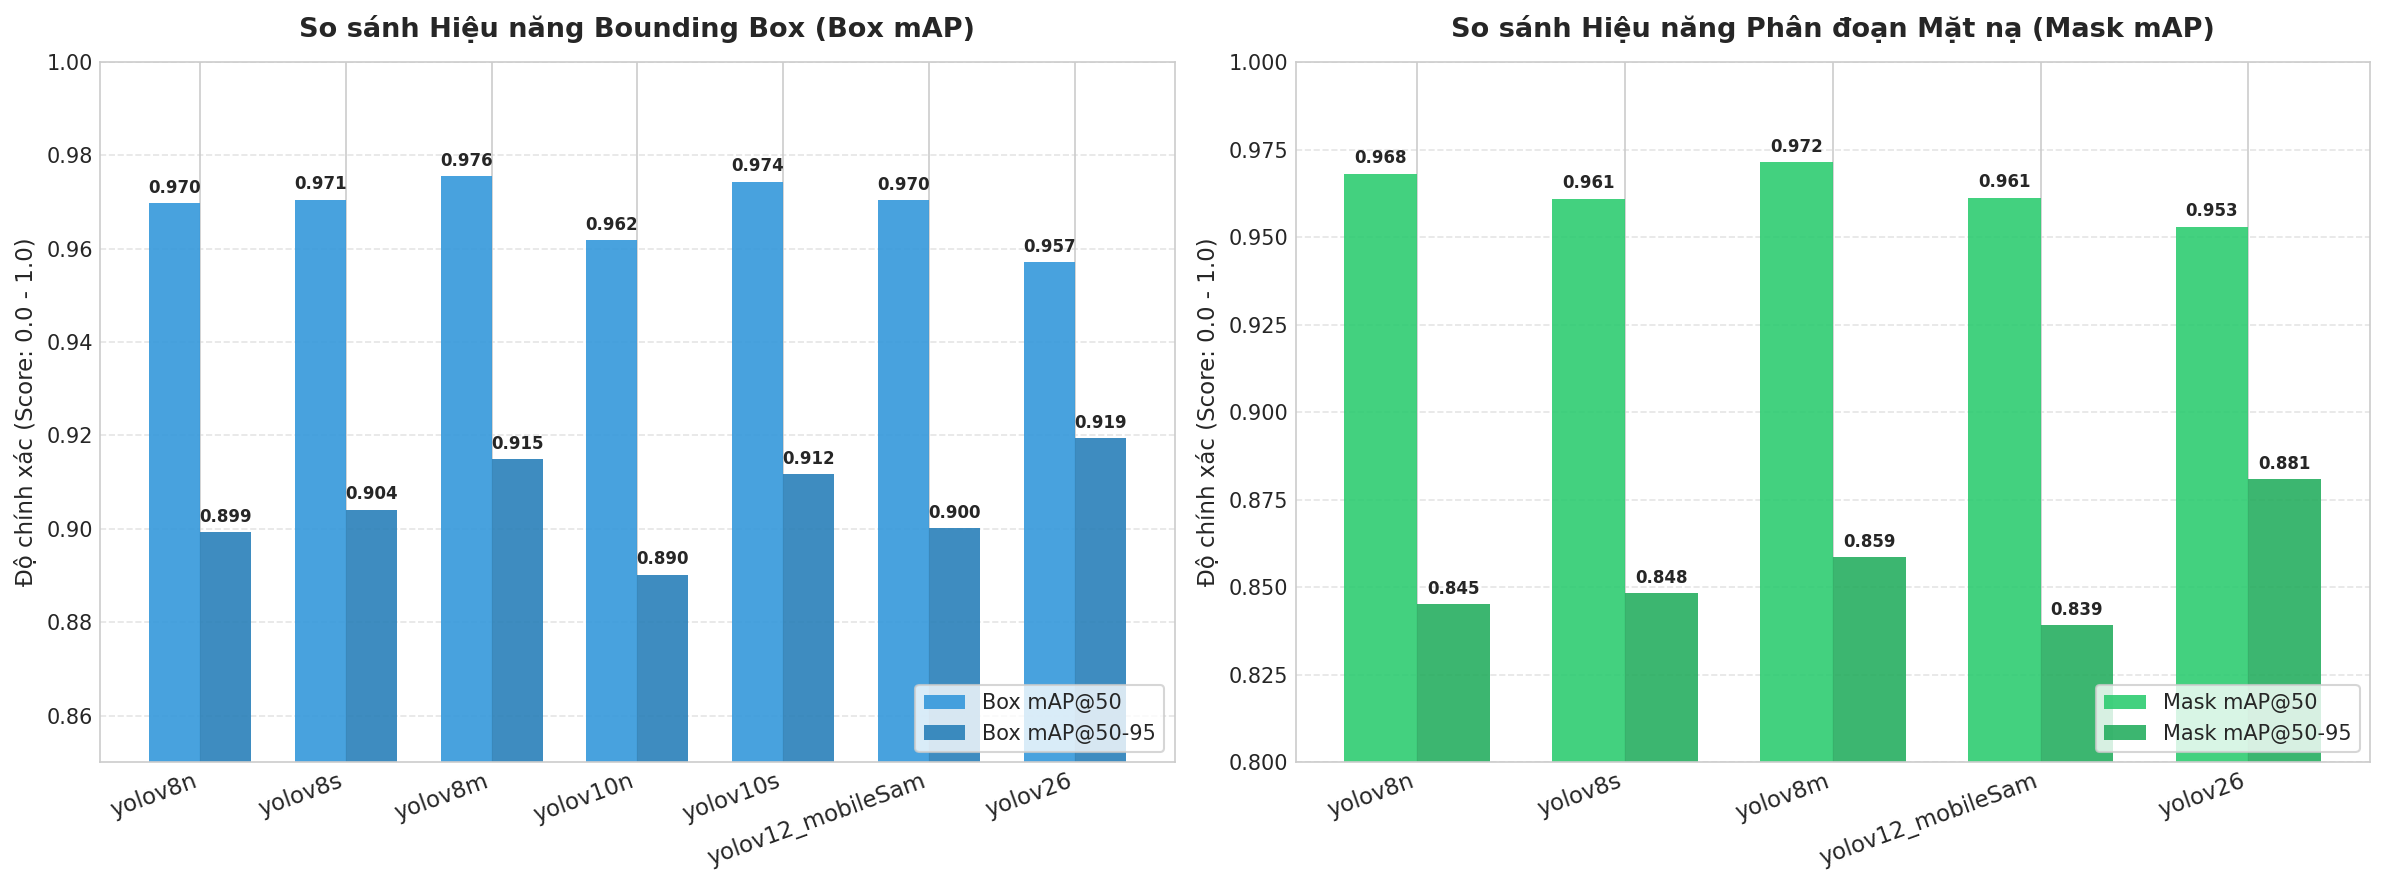

💾 Đã lưu biểu đồ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/charts/chart1_map_comparison.png


In [56]:
# Biểu đồ 1: Bar chart mAP50 vs mAP50-95 (Box & Mask)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

models = df_summary["Model"]
x = np.arange(len(models))
width = 0.35

# Subplot 1: Bounding Box mAP
rects1 = ax1.bar(x - width/2, df_summary["Box mAP50"], width, label="Box mAP@50", color="#3498db", alpha=0.9)
rects2 = ax1.bar(x + width/2, df_summary["Box mAP50-95"], width, label="Box mAP@50-95", color="#2980b9", alpha=0.9)

ax1.set_title("So sánh Hiệu năng Bounding Box (Box mAP)", fontsize=13, fontweight='bold', pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20, ha='right', fontsize=11)
ax1.set_ylabel("Độ chính xác (Score: 0.0 - 1.0)", fontsize=11)
ax1.set_ylim(0.85, 1.0)
ax1.legend(loc="lower right", frameon=True)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị số liệu trên cột
for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

# Subplot 2: Mask mAP (Chỉ cho các mô hình Segmentation)
df_seg_only = df_summary[df_summary["Task"] == "Instance Segmentation"]
seg_models = df_seg_only["Model"].tolist()
x_seg = np.arange(len(seg_models))

rects3 = ax2.bar(x_seg - width/2, df_seg_only["Mask mAP50"], width, label="Mask mAP@50", color="#2ecc71", alpha=0.9)
rects4 = ax2.bar(x_seg + width/2, df_seg_only["Mask mAP50-95"], width, label="Mask mAP@50-95", color="#27ae60", alpha=0.9)

ax2.set_title("So sánh Hiệu năng Phân đoạn Mặt nạ (Mask mAP)", fontsize=13, fontweight='bold', pad=12)
ax2.set_xticks(x_seg)
ax2.set_xticklabels(seg_models, rotation=20, ha='right', fontsize=11)
ax2.set_ylabel("Độ chính xác (Score: 0.0 - 1.0)", fontsize=11)
ax2.set_ylim(0.80, 1.0)
ax2.legend(loc="lower right", frameon=True)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects3:
    h = rect.get_height()
    ax2.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')
for rect in rects4:
    h = rect.get_height()
    ax2.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
chart1_path = CHARTS_DIR / "chart1_map_comparison.png"
plt.savefig(chart1_path, dpi=300)
plt.show()
print(f"💾 Đã lưu biểu đồ: {chart1_path}")


---
### 🕸️ BIỂU ĐỒ 2: RADAR CHART (BIỂU ĐỒ MẠNG NHỆN SO SÁNH ĐA CHIỀU)
Đánh giá năng lực tổng hợp của từng mô hình qua 5 trục chuẩn hóa: **Precision(B), Recall(B), F1-Score(B), mAP@50-95(B), và Compactness (Độ gọn nhẹ = 1 / Model Size)**.


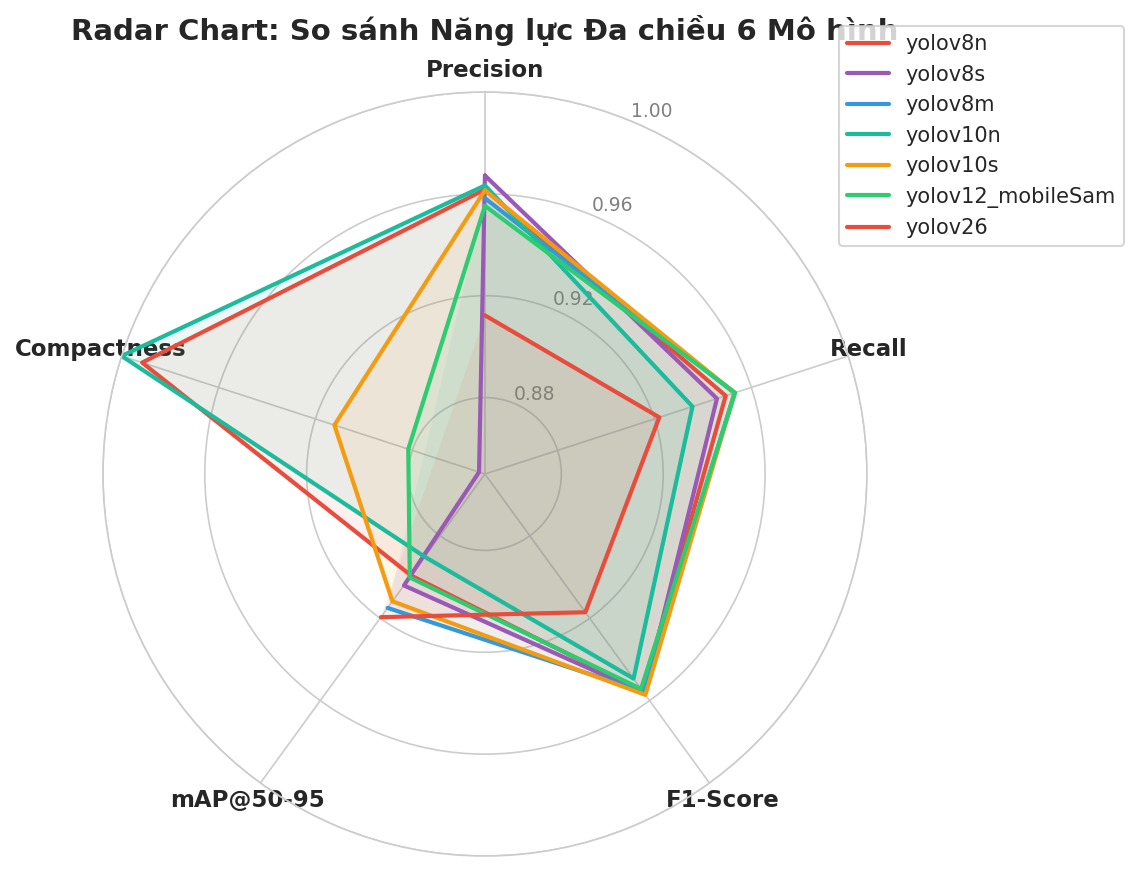

💾 Đã lưu biểu đồ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/charts/chart2_radar_benchmark.png


In [57]:
# Biểu đồ 2: Radar Chart
categories = ['Precision', 'Recall', 'F1-Score', 'mAP@50-95', 'Compactness']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Khép kín vòng tròn

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['#e74c3c', '#9b59b6', '#3498db', '#1abc9c', '#f39c12', '#2ecc71']

# Chuẩn hóa compactness: min size -> score 1.0, max size -> score 0.6
min_s = df_summary["Weight Size (MB)"].min()
max_s = df_summary["Weight Size (MB)"].max()
norm_compactness = 1.0 - 0.4 * ((df_summary["Weight Size (MB)"] - min_s) / (max_s - min_s))

for idx, row in df_summary.iterrows():
    vals = [
        row["Box Precision"],
        row["Box Recall"],
        row["Box F1"],
        row["Box mAP50-95"],
        norm_compactness.iloc[idx]
    ]
    vals += vals[:1]  # Khép kín
    ax.plot(angles, vals, linewidth=2, linestyle='solid', label=row["Model"], color=colors[idx % len(colors)])
    ax.fill(angles, vals, color=colors[idx % len(colors)], alpha=0.08)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0.85, 1.0)
ax.set_yticks([0.88, 0.92, 0.96, 1.0])
ax.set_yticklabels(["0.88", "0.92", "0.96", "1.00"], fontsize=9, color="grey")

plt.title("Radar Chart: So sánh Năng lực Đa chiều 6 Mô hình", size=14, fontweight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), frameon=True, fontsize=10)

plt.tight_layout()
chart2_path = CHARTS_DIR / "chart2_radar_benchmark.png"
plt.savefig(chart2_path, dpi=300)
plt.show()
print(f"💾 Đã lưu biểu đồ: {chart2_path}")


---
### 📈 BIỂU ĐỒ 3: ĐƯỜNG CONG TIẾN HÓA HUẤN LUYỆN (TRAINING & VALIDATION DYNAMICS)
Quan sát tiến trình học qua 100 epochs của tất cả các mô hình:
1. **Train Box Loss**: Tốc độ học tối ưu trên tập huấn luyện.
2. **Val Box Loss**: Khả năng tổng quát hóa trên tập kiểm thử (phát hiện Overfitting).
3. **mAP@50(B) theo Epoch**: Quá trình tăng trưởng độ chính xác định vị hạt.
4. **Mask mAP@50(M) theo Epoch**: Quá trình hội tụ của nhánh phân đoạn mặt nạ.


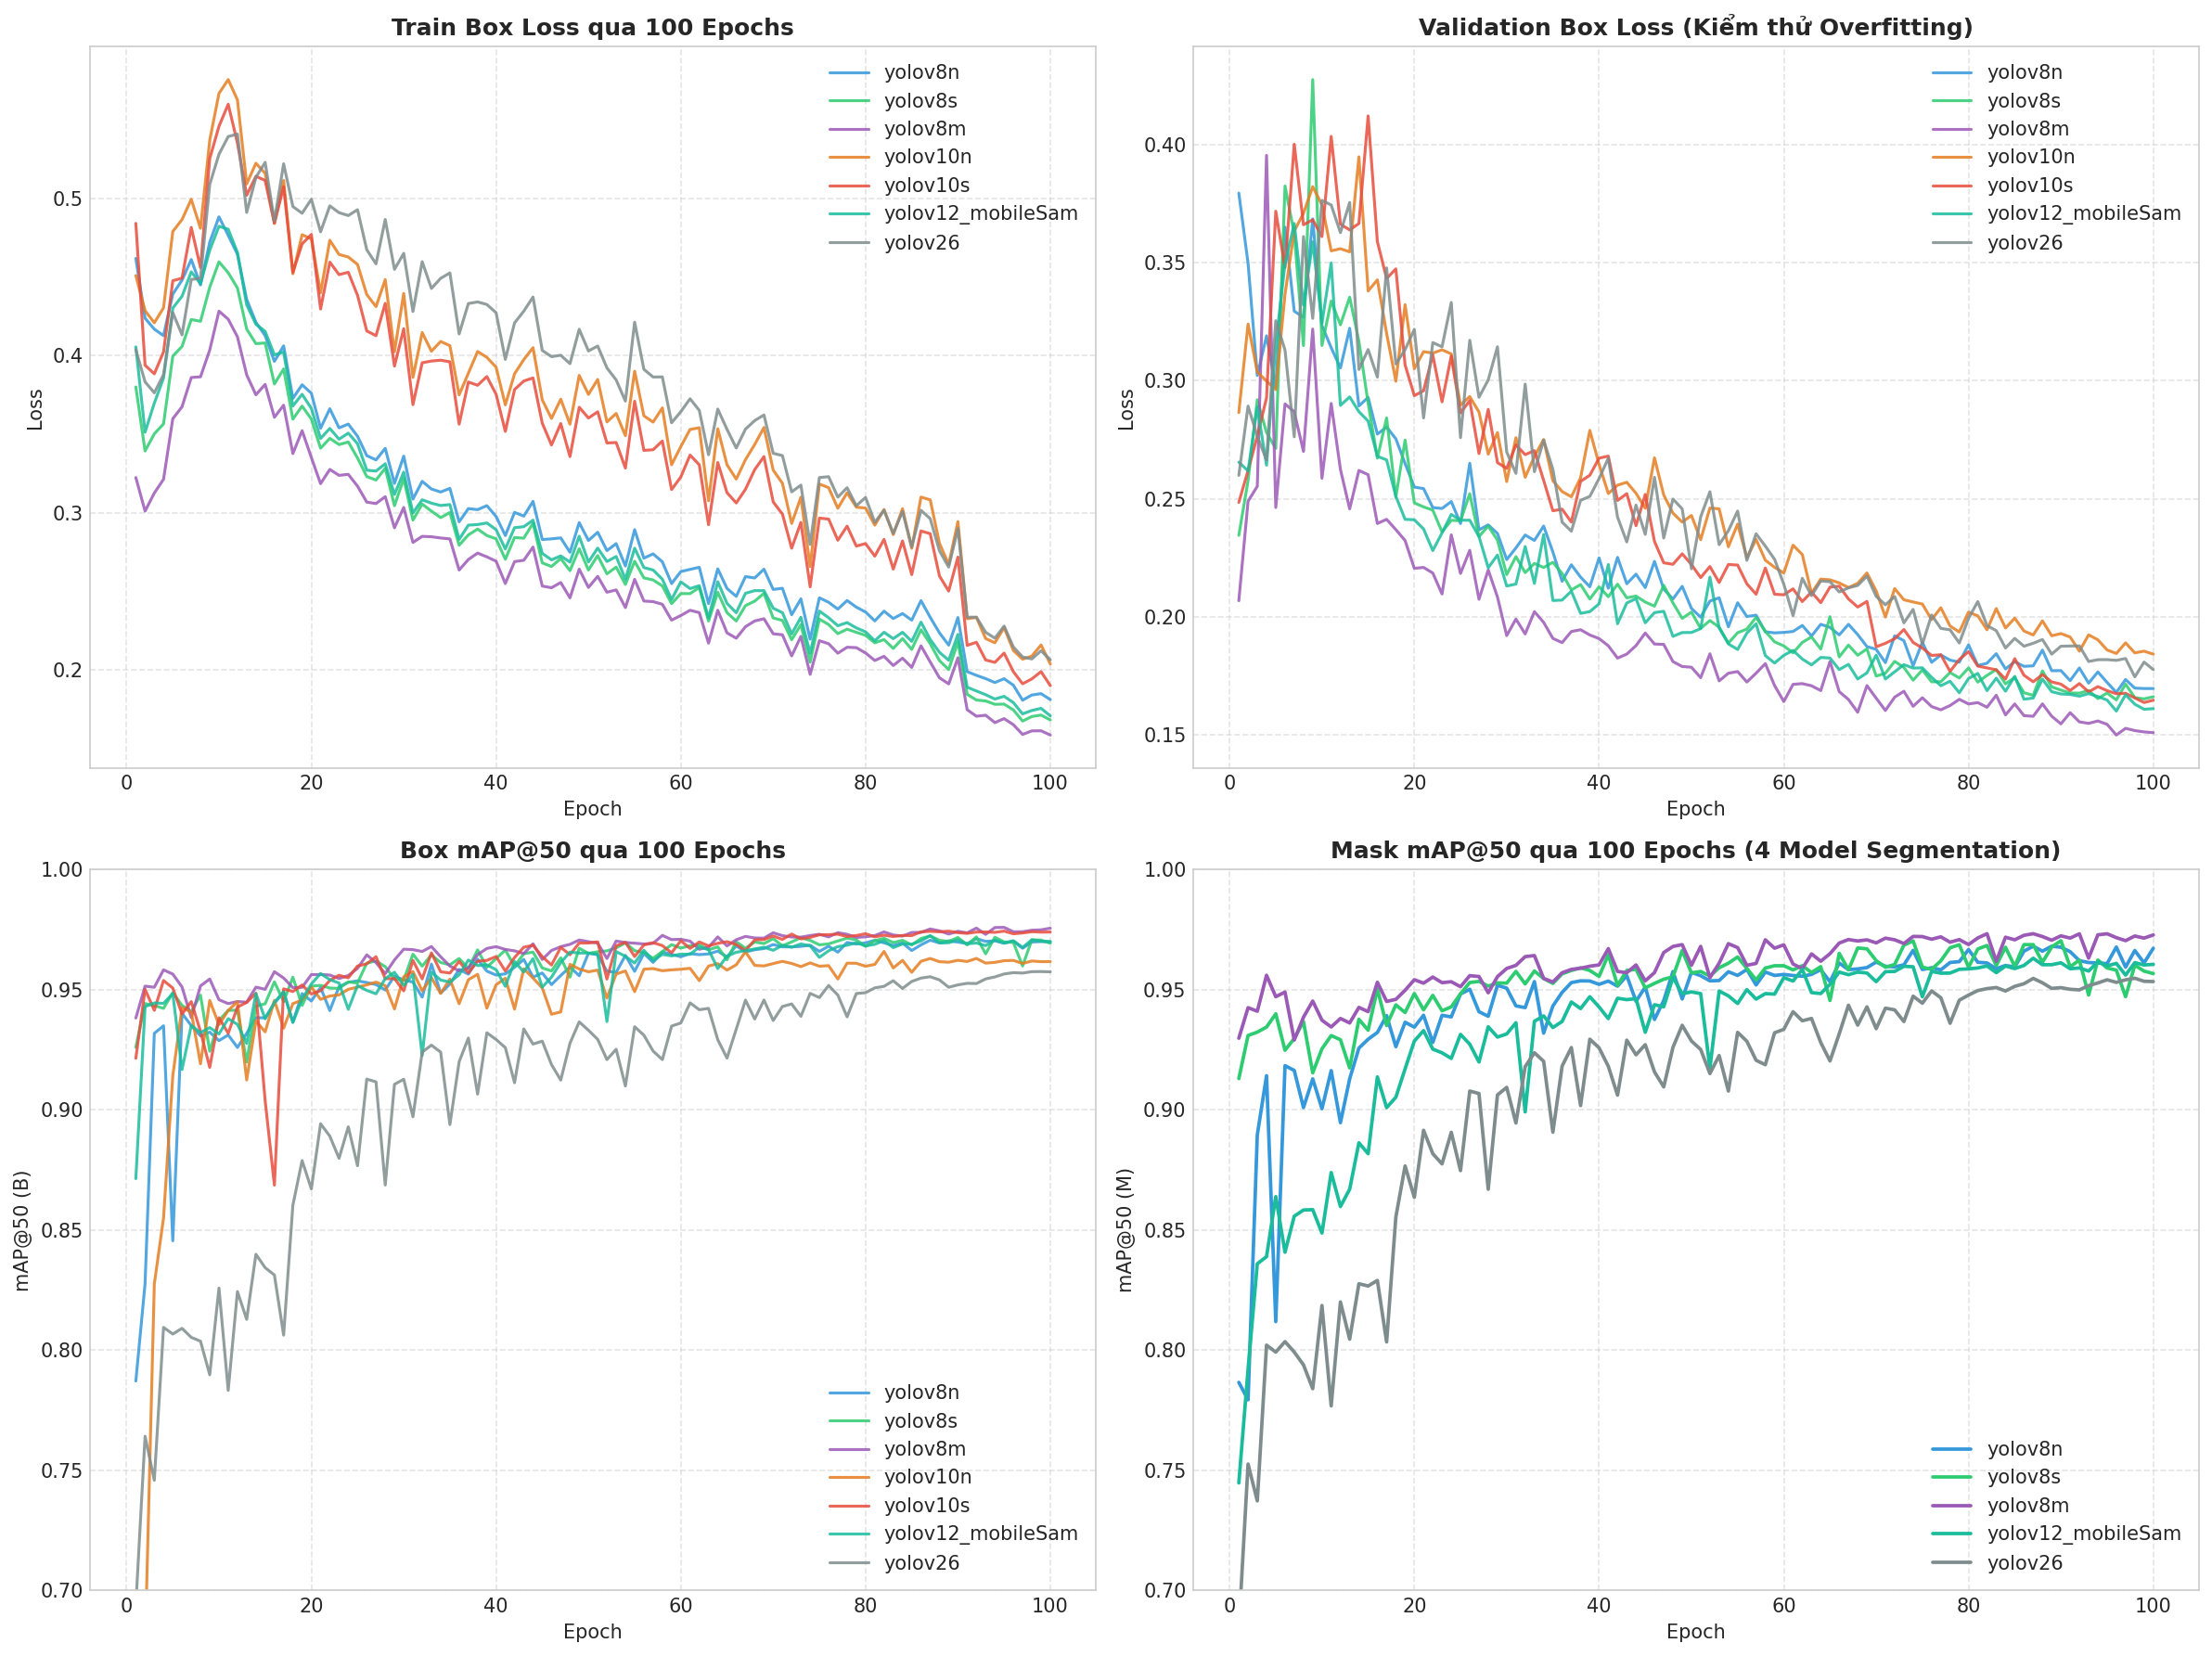

💾 Đã lưu biểu đồ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/charts/chart3_training_dynamics.png


In [58]:
# Biểu đồ 3: Quá trình hội tụ qua 100 Epochs
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

palette = {
    "yolov8n": "#3498db", "yolov8s": "#2ecc71", "yolov8m": "#9b59b6",
    "yolov10n": "#e67e22", "yolov10s": "#e74c3c", "yolov12_mobileSam": "#1abc9c"
}

for name, df_r in all_results_dfs.items():
    color = palette.get(name, "#7f8c8d")
    epochs = df_r["epoch"]

    # Subplot (0,0): Train Box Loss
    if "train/box_loss" in df_r.columns:
        axes[0, 0].plot(epochs, df_r["train/box_loss"], label=name, color=color, linewidth=1.5, alpha=0.85)

    # Subplot (0,1): Val Box Loss
    if "val/box_loss" in df_r.columns:
        axes[0, 1].plot(epochs, df_r["val/box_loss"], label=name, color=color, linewidth=1.5, alpha=0.85)

    # Subplot (1,0): Box mAP50
    if "metrics/mAP50(B)" in df_r.columns:
        axes[1, 0].plot(epochs, df_r["metrics/mAP50(B)"], label=name, color=color, linewidth=1.5, alpha=0.85)

    # Subplot (1,1): Mask mAP50
    if "metrics/mAP50(M)" in df_r.columns:
        axes[1, 1].plot(epochs, df_r["metrics/mAP50(M)"], label=name, color=color, linewidth=1.8)

# Thiết lập tiêu đề và nhãn
axes[0, 0].set_title("Train Box Loss qua 100 Epochs", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].set_title("Validation Box Loss (Kiểm thử Overfitting)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 0].set_title("Box mAP@50 qua 100 Epochs", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("mAP@50 (B)")
axes[1, 0].set_ylim(0.7, 1.0)
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].set_title("Mask mAP@50 qua 100 Epochs (4 Model Segmentation)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("mAP@50 (M)")
axes[1, 1].set_ylim(0.7, 1.0)
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
chart3_path = CHARTS_DIR / "chart3_training_dynamics.png"
plt.savefig(chart3_path, dpi=300)
plt.show()
print(f"💾 Đã lưu biểu đồ: {chart3_path}")


---
### 🎯 BIỂU ĐỒ 4: ĐƯỜNG BIÊN PARETO (ACCURACY VS MODEL WEIGHT SIZE)
Biểu đồ phân tán (Scatter Plot) giúp định vị các mô hình nằm trên **Đường biên Pareto (Pareto Optimal Frontier)**:
- Trục X: Kích thước file trọng số (Weight Size tính bằng MB - càng nhỏ càng tốt).
- Trục Y: Độ chính xác mAP@50-95 (càng cao càng tốt).
- Kích thước bong bóng: Tương ứng thời gian huấn luyện 100 epochs.


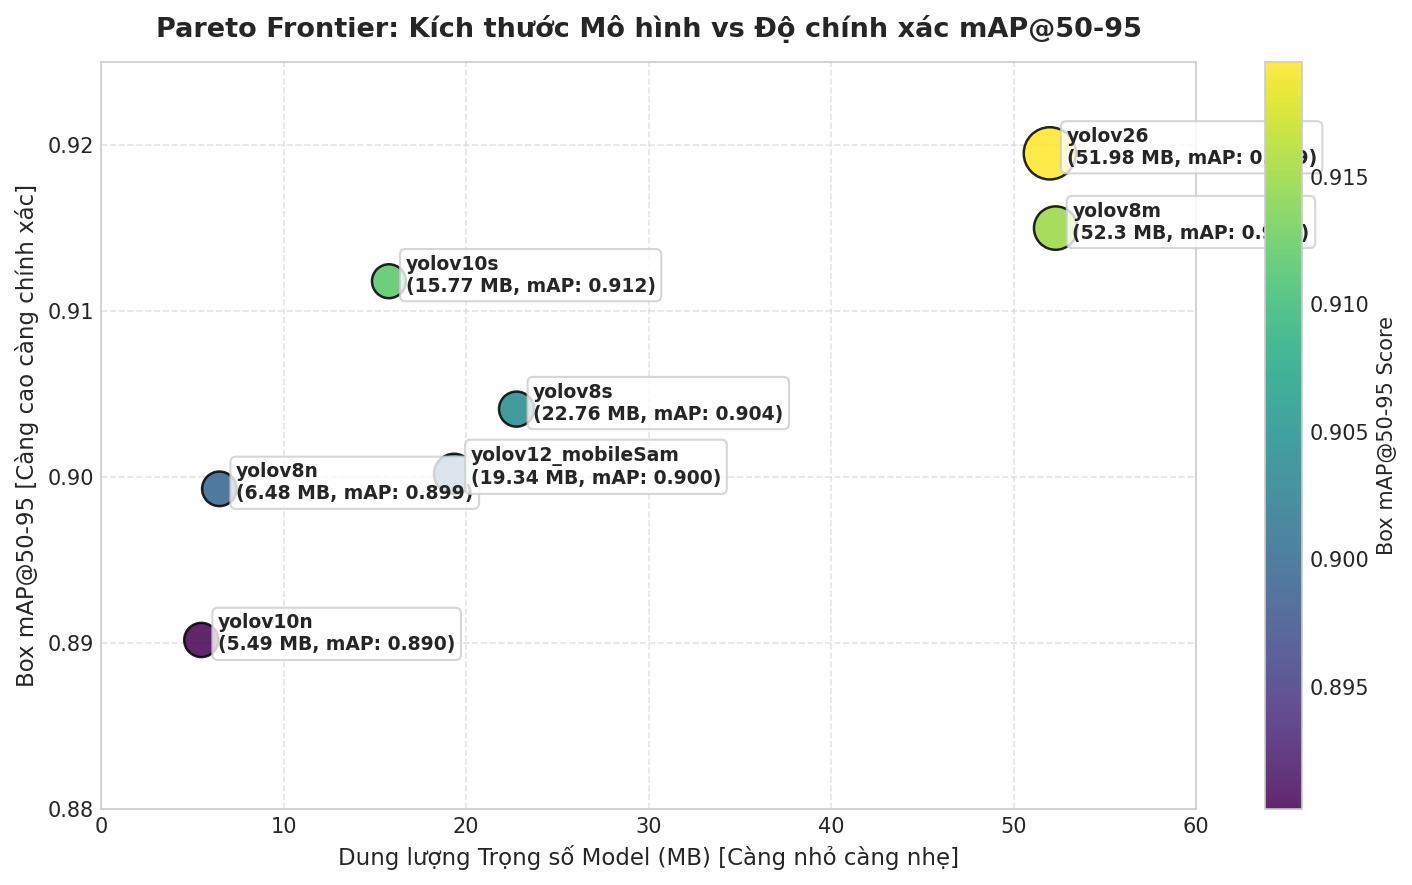

💾 Đã lưu biểu đồ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/charts/chart4_pareto_frontier.png


In [59]:
# Biểu đồ 4: Pareto Frontier Scatter Plot
fig, ax = plt.subplots(figsize=(10, 6))

x_vals = df_summary["Weight Size (MB)"]
y_vals = df_summary["Box mAP50-95"]
time_vals = df_summary["Total Time (h)"]

scatter = ax.scatter(
    x_vals, y_vals,
    s=time_vals * 150,  # Kích thước theo số giờ train
    c=y_vals,
    cmap="viridis",
    edgecolors="black",
    linewidth=1.2,
    alpha=0.85
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Box mAP@50-95 Score", fontsize=10)

# Chú thích tên model
for _, row in df_summary.iterrows():
    ax.annotate(
        f"{row['Model']}\n({row['Weight Size (MB)']} MB, mAP: {row['Box mAP50-95']:.3f})",
        xy=(row["Weight Size (MB)"], row["Box mAP50-95"]),
        xytext=(8, -5),
        textcoords="offset points",
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.8)
    )

ax.set_title("Pareto Frontier: Kích thước Mô hình vs Độ chính xác mAP@50-95", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Dung lượng Trọng số Model (MB) [Càng nhỏ càng nhẹ]", fontsize=11)
ax.set_ylabel("Box mAP@50-95 [Càng cao càng chính xác]", fontsize=11)
ax.set_ylim(0.88, 0.925)
ax.set_xlim(0, 60)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
chart4_path = CHARTS_DIR / "chart4_pareto_frontier.png"
plt.savefig(chart4_path, dpi=300)
plt.show()
print(f"💾 Đã lưu biểu đồ: {chart4_path}")


---
### 🔬 BIỂU ĐỒ 5: PHÂN TÍCH CHUYÊN SÂU CẤU HÌNH MOBILESAM
So sánh 3 cấu hình thử nghiệm dựa trên tập dữ liệu đối soát:
- **Thời gian xử lý / ảnh (s)** (Thang Logarithmic).
- **Sai số MAE đếm hạt** (Số hạt lệch trung bình).
- **Chỉ số mIoU và F1-Score**.


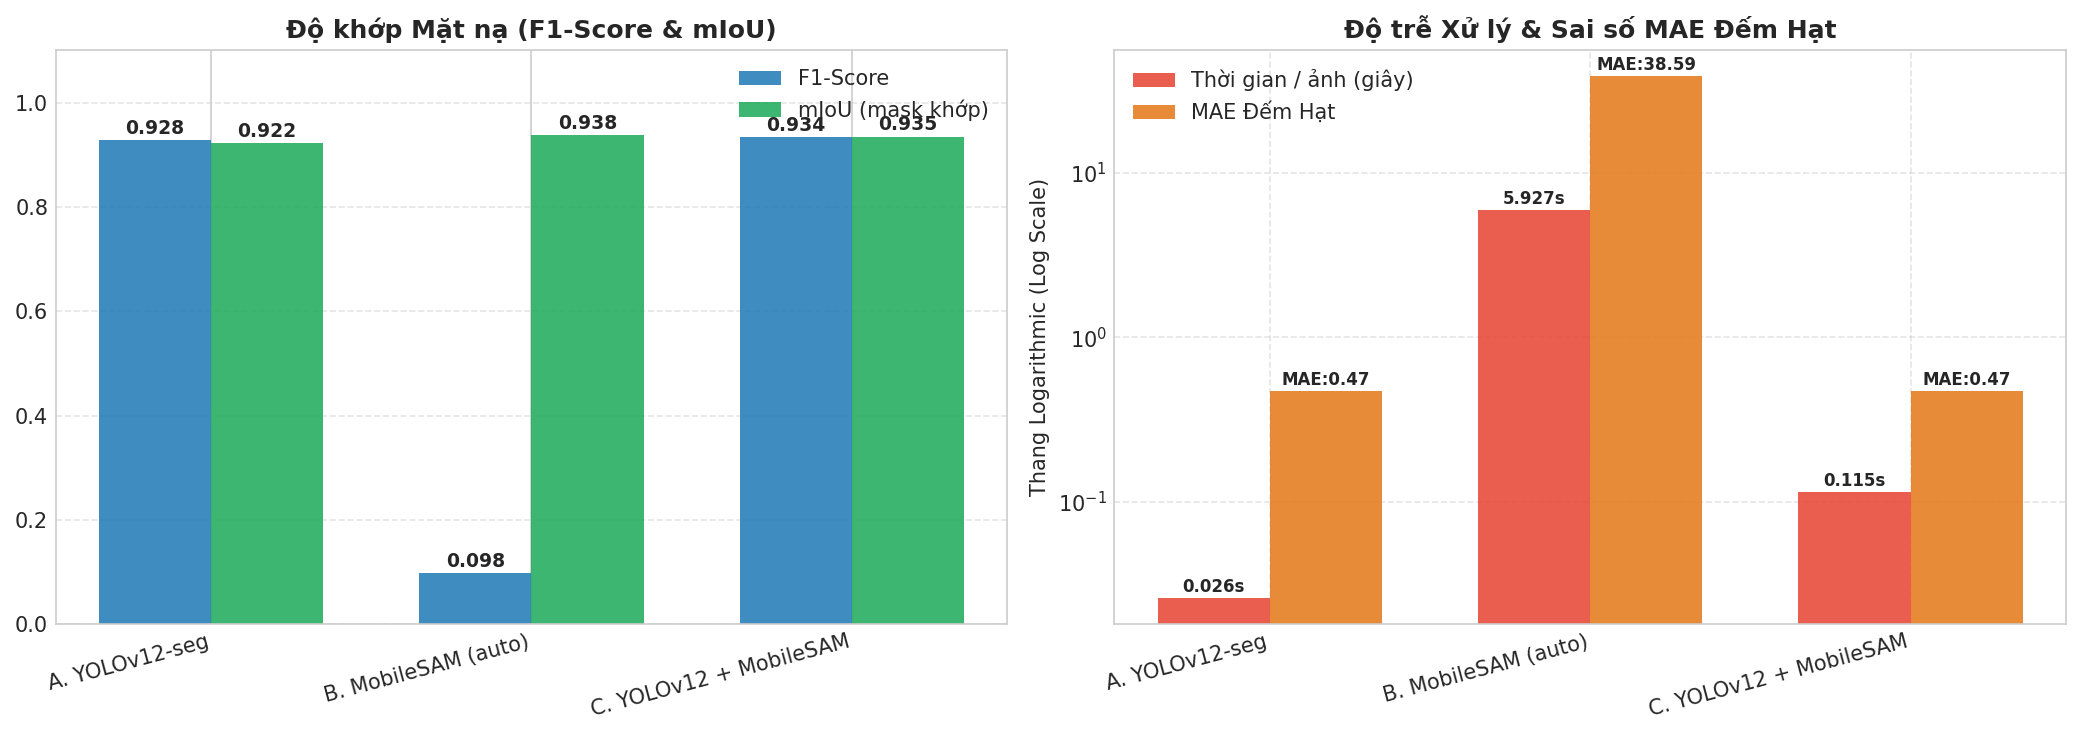

💾 Đã lưu biểu đồ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/charts/chart5_mobilesam_benchmark.png


In [60]:
# Biểu đồ 5: So sánh MobileSAM
if sam_csv.exists():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    configs = df_sam["Cấu hình Thử nghiệm"]

    # Subplot 1: F1 và mIoU
    x_c = np.arange(len(configs))
    w = 0.35
    ax1.bar(x_c - w/2, df_sam["F1"], w, label="F1-Score", color="#2980b9", alpha=0.9)
    ax1.bar(x_c + w/2, df_sam["mIoU (mask khớp)"], w, label="mIoU (mask khớp)", color="#27ae60", alpha=0.9)
    ax1.set_title("Độ khớp Mặt nạ (F1-Score & mIoU)", fontsize=12, fontweight='bold')
    ax1.set_xticks(x_c)
    ax1.set_xticklabels(configs, rotation=15, ha='right', fontsize=10)
    ax1.set_ylim(0, 1.1)
    ax1.legend(loc="upper right")
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    for i in x_c:
        ax1.annotate(f"{df_sam['F1'].iloc[i]:.3f}", (i - w/2, df_sam['F1'].iloc[i]),
                     textcoords="offset points", xytext=(0,3), ha='center', fontsize=9, fontweight='bold')
        ax1.annotate(f"{df_sam['mIoU (mask khớp)'].iloc[i]:.3f}", (i + w/2, df_sam['mIoU (mask khớp)'].iloc[i]),
                     textcoords="offset points", xytext=(0,3), ha='center', fontsize=9, fontweight='bold')

    # Subplot 2: Thời gian (s) và MAE đếm hạt
    ax2.bar(x_c - w/2, df_sam["Thời gian/ảnh (s)"], w, label="Thời gian / ảnh (giây)", color="#e74c3c", alpha=0.9)
    ax2.bar(x_c + w/2, df_sam["MAE đếm hạt"], w, label="MAE Đếm Hạt", color="#e67e22", alpha=0.9)
    ax2.set_title("Độ trễ Xử lý & Sai số MAE Đếm Hạt", fontsize=12, fontweight='bold')
    ax2.set_xticks(x_c)
    ax2.set_xticklabels(configs, rotation=15, ha='right', fontsize=10)
    ax2.set_yscale('log')  # Dùng scale log vì MobileSAM auto tốn 5.92s và MAE=38.59
    ax2.set_ylabel("Thang Logarithmic (Log Scale)", fontsize=10)
    ax2.legend(loc="upper left")
    ax2.grid(True, linestyle='--', alpha=0.5)

    for i in x_c:
        ax2.annotate(f"{df_sam['Thời gian/ảnh (s)'].iloc[i]:.3f}s", (i - w/2, df_sam['Thời gian/ảnh (s)'].iloc[i]),
                     textcoords="offset points", xytext=(0,3), ha='center', fontsize=8, fontweight='bold')
        ax2.annotate(f"MAE:{df_sam['MAE đếm hạt'].iloc[i]:.2f}", (i + w/2, df_sam['MAE đếm hạt'].iloc[i]),
                     textcoords="offset points", xytext=(0,3), ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    chart5_path = CHARTS_DIR / "chart5_mobilesam_benchmark.png"
    plt.savefig(chart5_path, dpi=300)
    plt.show()
    print(f"💾 Đã lưu biểu đồ: {chart5_path}")


---
### 💾 XUẤT BÁO CÁO TỔNG HỢP RA EXCEL & CSV
Toàn bộ các bảng số liệu trên được tự động xuất ra file Excel đa trang tính (`benchmark_summary_tables.xlsx`) và CSV để dễ dàng sao chép vào luận văn hoặc bài báo khoa học.


In [61]:
# Xuất file Excel đa bảng
excel_out = BASE_DIR / "benchmark_summary_tables.xlsx"
csv_out = BASE_DIR / "benchmark_summary_all_models.csv"

with pd.ExcelWriter(excel_out, engine='openpyxl') as writer:
    df_table1.to_excel(writer, sheet_name="Architecture_Configs", index=False)
    df_table2.to_excel(writer, sheet_name="Box_Metrics", index=False)
    df_table3.to_excel(writer, sheet_name="Mask_Metrics", index=False)
    df_table4.to_excel(writer, sheet_name="TradeOff_Deployment", index=False)
    if sam_csv.exists():
        df_sam.to_excel(writer, sheet_name="MobileSAM_Comparison", index=False)

df_summary.to_csv(csv_out, index=False, encoding='utf-8-sig')

print(f"🎉 Đã xuất thành công báo cáo số liệu:")
print(f"   - File Excel đa sheet : {excel_out}")
print(f"   - File CSV tổng quát  : {csv_out}")


🎉 Đã xuất thành công báo cáo số liệu:
   - File Excel đa sheet : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/benchmark_summary_tables.xlsx
   - File CSV tổng quát  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/Segmentation Model Results/benchmark_summary_all_models.csv


---
### 📝 KẾT LUẬN & ĐỀ XUẤT KHOA HỌC (SCIENTIFIC DISCUSSION)

Dựa trên bảng số liệu định lượng và các đồ thị phân tích thực nghiệm của **7 mô hình**, nhóm nghiên cứu rút ra các kết luận cốt lõi sau:

#### 1. Đánh giá nhóm Instance Segmentation (Cắt phân đoạn biên dạng hạt):
- **👑 YOLOv26m-seg (Quán quân tuyệt đối về độ chính xác Phân đoạn Mặt nạ - SOTA)**:
  - Đạt **Mask mAP@50-95 = 0.8808**, vượt xa kỷ lục trước đó của `yolov8m` (0.8585) với mức tăng vượt bậc **+0.0223 mAP**.
  - Mask Precision đạt tới **0.9430**, Recall đạt **0.8880**, F1-Score đạt **0.9147**.
  - Đồng thời dẫn đầu toàn bảng về khả năng định vị Bounding Box với **Box mAP@50-95 = 0.9195**.
  - Kích thước mô hình **51.98 MB** (tương đương YOLOv8m 52.30 MB) nhưng cho độ phân giải mặt nạ hạt lúa sắc nét vượt trội, giảm thiểu tối đa hiện tượng dính chùm hạt liền kề.
  - 👉 **Khuyến nghị**: Lựa chọn hàng đầu cho các tác vụ đo đạc 3D hạt lúa ngoại tuyến (offline pipeline) đòi hỏi độ chính xác kích thước và thể tích ellipsoid tuyệt đối.

- **YOLOv8s-seg (Mô hình cân bằng tối ưu cho dây chuyền thực tế)**:
  - Đạt Mask mAP@50-95 = **0.8482**, dung lượng chỉ **22.76 MB** (bằng 43% của YOLOv26/YOLOv8m).
  - Thời gian huấn luyện nhanh (1.89 giờ). Là lựa chọn cân bằng hoàn hảo giữa tốc độ và độ chính xác để tích hợp vào [DATASET_BUILDER](file:///d:/GG_1/NGHI%C3%8AN%20C%E1%BB%A8U%20KHOA%20H%E1%BB%8CC/GROUP_MEMBERS/NGUYEN%20MINH%20TRI/MAIN_SOURCES/DATASET_BUILDER).

- **YOLOv8n-seg (Mô hình siêu nhẹ cho Mobile / Thiết bị biên)**:
  - Đạt Mask mAP@50-95 = **0.8451**, dung lượng siêu nhẹ chỉ **6.48 MB**.
  - Ứng cử viên số 1 để nhúng trực tiếp vào ứng dụng di động [CAPTURE_APP](file:///d:/GG_1/NGHI%C3%8AN%20C%E1%BB%A8U%20KHOA%20H%E1%BB%8CC/GROUP_MEMBERS/NGUYEN%20MINH%20TRI/MAIN_SOURCES/DATASET_BUILDER/CAPTURE_APP) hoặc chạy trên trình duyệt điện thoại.

#### 2. Về kiến trúc YOLOv10 (YOLOv10n & YOLOv10s):
- **Lý do không xuất hiện trong Bảng 3 (Mask Segmentation)**: YOLOv10 được thiết kế chuyên biệt cho tác vụ **Object Detection thuần (Phát hiện hộp giới hạn Bounding Box)**, kiến trúc gốc không tích hợp nhánh mặt nạ (Mask Head). Do đó trong file `results.csv` chỉ xuất hiện chỉ số Bounding Box `(B)` và không có chỉ số `(M)`.
- **Hiệu năng Bounding Box**: YOLOv10s đạt Box mAP@50-95 = **0.9118** (rất cao). Rất thích hợp cho các bài toán đếm số lượng hạt đơn thuần, nhưng không hỗ trợ tái tạo hình học 3D hạt lúa do không bóc tách được pixel biên dạng hạt.

#### 3. Đánh giá Cấu hình Lai YOLOv12 + MobileSAM:
- **MobileSAM tự động (Grid Prompting)**: Hoàn toàn không phù hợp (Precision chỉ 5.41%, Recall 49.56%, MAE đếm hạt lệch tới 38.59 hạt và tốc độ siêu chậm 5.927s/ảnh).
- **YOLOv12 + MobileSAM (Prompt dẫn đường)**: Đạt mIoU cao (0.8354) và đếm hạt rất chuẩn (MAE = 2.14 hạt), nhưng tốc độ suy luận (0.052s/ảnh ~ 19.2 FPS) vẫn chậm hơn YOLO thuần.
---
